# IMBH population model
----
We consider the same population as in the MPSAC paper (https://arxiv.org/pdf/2307.10421) but with a higher maximum mass cutoff (from $1000\,\rm{M_\odot}$ to $5000\,\rm{M_\odot}$)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from abc import ABC, abstractmethod
from astropy.cosmology import Planck18 as cosmo

%config InlineBackend.figure_format = 'retina'
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18
})

## Defining the Models

### Auxiliary Functions

In [2]:
def inverse_cdf_sampling(fun, size, prange, res=1e5, seed=42, **kwargs):
    """
    Sample from a probability distribution using inverse cdf sampling.

    :param function fun: PDF to sample from. It has to take an array of values as input and return an array containing their probabilities.
    :param int size: Size of the sample to generate.
    :param tuple prange: Range of the sample to generate.

    :return: Samples extracted from the desired PDF.
    :rtype: array
    """
    np.random.seed(seed)

    # generate uniform samples
    u = np.random.uniform(size=size)

    # compute inverse cdf
    x = np.linspace(prange[0],prange[1], int(res))
    y = fun(x, **kwargs)
    cdf_y = np.cumsum(y)
    cdf_y = cdf_y/cdf_y.max()
    res = np.interp(u, cdf_y,x)
    return res


def inverse_cdf_sampling_uppercond(pdf, lower, upper):

    nSamples = len(upper)
    res = 100000
    eps=1e-02
    x = np.linspace(lower+eps, upper.max()-eps, res)
    cdf = np.cumsum(pdf(x))
    cdf = cdf / cdf[-1]
    probTilUpper = np.interp(upper, x, cdf)
    return np.interp(probTilUpper*np.random.uniform(size=nSamples), cdf, x)

### Mass Distribution

In [3]:
class MassDistribution(ABC):
    '''
    Abstract class to compute mass distributions.

    :param list parameters: List containing the parameters of the mass model.
    :param dict, optional hyperparameters: Dictionary containing the hyperparameters of the mass model as keys and their fiducial value as entry.
    :param dict, optional priorlims_parameters: Dictionary containing the parameters of the mass model as keys and their prior limits value as entry, given as a tuple :math:`(l, h)`.
    '''
    
    def __init__(self, object_type='BBH'):
        self.par_list = []
        self.hyperpar_dict = {}
        self.priorlims_dict = {}
        self.object_type = object_type

    def set_parameters(self, parameters):
        '''
        Setter method for the parameters of the mass model.

        :param list parameters: List containing the parameters of the mass model.
        '''
        self.par_list = parameters

    def set_hyperparameters(self, hyperparameters):
        '''
        Setter method for the hyperparameters of the mass model.

        :param dict new_hyperparameters: Dictionary containing the hyperparameters of the mass model as keys and their new value as entry.
        '''
        self.hyperpar_dict = hyperparameters

    def update_hyperparameters(self, new_hyperparameters):
        '''
        Method to update the hyperparameters of the mass model.

        :param dict new_hyperparameters: Dictionary containing the new hyperparameters of the mass model as keys and their new value as entry.
        '''
        for key in new_hyperparameters.keys():
            if key in self.hyperpar_dict.keys():
                self.hyperpar_dict[key] = new_hyperparameters[key]
            else:
                raise ValueError('The hyperparameter '+key+' is not present in the hyperparameter dictionary.')

    def set_priorlimits(self, limits):
        '''
        Setter method for the prior limits on the parameters of the mass model.

        :param dict limits: Dictionary containing the parameters of the mass model as keys and their prior limits value as entry, given as a tuple :math:`(l, h)`.
        '''
        self.priorlims_dict = limits

    def update_priorlimits(self, new_limits):
        '''
        Method to update the prior limits on the parameters of the mass model.
        
        :param dict new_limits: Dictionary containing the new prior limits on the parameters of the mass model as keys and their new value as entry, given as a tuple :math:`(l, h)`.
        '''
        for key in new_limits.keys():
            if key in self.priorlims_dict.keys():
                self.priorlims_dict[key] = new_limits[key]
            else:
                raise ValueError('The parameter '+key+' is not present in the prior limits dictionary.')

    def _isin_prior_range(self, par,  val):
        '''
        Function to check if a value is in the prior range of a parameter.

        :param str par: Parameter name.
        :param float val: Parameter value.
        :return: Boolean value.
        :rtype: bool
        '''

        return (val >= self.priorlims_dict[par][0]) & (val <= self.priorlims_dict[par][1])
    
    @abstractmethod
    def mass_function(self,):
        '''
        Mass function of the model.

        :return: Mass function value.
        :rtype: float
        '''
        pass

    @abstractmethod
    def sample_population(self, size):
        '''
        Function to sample the mass distribution.

        :param int size: number of samples
        '''
        pass


class TruncatedPowerLaw_MassDistribution(MassDistribution):
    '''
    Truncated mass model

    Parameters:
        * alpha_m: Spectral index for the power-law of the primary mass distribution
        * beta_q: Spectral index for the power-law of the mass ratio distribution
        * m_min: Minimum mass of the power-law component of the mass distribution.
        * m_max: Maximum mass of the power-law component of the mass distribution.
    
    :param list parameters: List containing the parameters of the mass model.
    :param dict, optional hyperparameters: Dictionary containing the hyperparameters of the mass model as keys and their fiducial value as entry.
    :param dict, optional priorlims_parameters: Dictionary containing the parameters of the mass model as keys and their prior limits value as entry, given as a tuple :math:`(l, h)`.

    '''

    def __init__(self, hyperparameters=None, priorlims_parameters=None):

        self.expected_hyperpars = ['alpha_m', 'beta_q', 'm_min', 'm_max']
        super().__init__()

        self.set_parameters(['m1_src', 'm2_src'])

        if hyperparameters is not None:
            self.set_hyperparameters(hyperparameters)
        else:
            print('Expected hyperparameters: ', self.expected_hyperpars)
            basevalues = {'alpha_m':0.75, 'beta_q':0.1, 'm_min':5., 'm_max':45.}
            print('Base values are: ', list(basevalues.items()))
            self.set_hyperparameters(basevalues)
        
        if priorlims_parameters is not None:
            self.set_priorlimits(priorlims_parameters)
        else:
            # Define the prior limits for 'm1_src' and 'q'
            self.set_priorlimits({'m1_src': (5., 100.), 'm2_src': (5., 100.)})
        
        self.derivative_par_nums = {'alpha_m':0, 'beta_q':1, 'm_min':2, 'm_max':3}

    def _mass1_function(self, m1_src, alpha_m=None, mmin=None, mmax=None):
        '''
        Mass distribution of the primary object.
        
        :param array m1_src: Primary mass.
        :param float, optional alpha_m: Spectral index for the power-law of the primary mass distribution.
        :param float, optional mmin: Minimum mass of the power-law component of the mass distribution.
        :param float, optional mmax: Maximum mass of the power-law component of the mass distribution.
        
        :return: Mass function value at the input masses.
        :rtype: array
        '''

        alpha = self.hyperpar_dict['alpha_m'] if alpha_m is None else alpha_m
        mmin  = self.hyperpar_dict['m_min'] if mmin is None else mmin
        mmax  = self.hyperpar_dict['m_max'] if mmax is None else mmax

        where_compute   = (m1_src>=mmin) & (m1_src<=mmax)
        pm1             = (m1_src**(-alpha))
        return np.where(where_compute, pm1, 0.)
    
    def _mass2_function(self, m2_src, beta_q=None, m_min=None):
        '''
        Mass distribution of the secondary object.
        
        :param array m2_src: Secondary mass.
        :param array m1_src: Primary mass.
        :param float, optional beta_q: Spectral index for the power-law of the mass ratio distribution.
        :param float, optional m_min: Minimum mass of the power-law component of the mass distribution.
        
        :return: Mass function value at the input masses.
        :rtype: array
        '''

        beta  = self.hyperpar_dict['beta_q'] if beta_q is None else beta_q
        mmin  = self.hyperpar_dict['m_min'] if m_min is None else m_min

        where_compute = m2_src>=mmin
        pm2           = (m2_src)**(beta)#/norm
        return np.where(where_compute, pm2, 0.)
    
    def _Cnorm(self, m1_src, beta_q=None, m_min=None):
        '''
        Inverse integral of p(m1, m2) dm2 (i.e. C(m1) in the LVC notation).
        
        :param array m1_src: Primary mass (i.e. the upper bound of the integrals).
        :param float, optional beta_q: Spectral index for the power-law of the mass ratio distribution.
        :param float, optional m_min: Minimum mass of the power-law component of the mass distribution.
        
        :return: Inverse integral of p(m1, m2) dm2.
        :rtype: array
        '''
        beta  = self.hyperpar_dict['beta_q'] if beta_q is None else beta_q
        mmin  = self.hyperpar_dict['m_min'] if m_min is None else m_min

        if beta==1:
            C=np.log(m1_src/mmin)
        else:
            C=(m1_src**(1+beta)-mmin**(1+beta))/(1+beta)
        
        return 1./C

    def _norm(self, alpha_m=None, m_min=None, m_max=None, sigma_l=None, sigma_h=None):
        '''
        Normalization of the primary mass function.
        
        :param float, optional alpha_m: Spectral index for the power-law of the primary mass distribution.
        :param float, optional m_min: Minimum mass of the power-law component of the mass distribution.
        :param float, optional m_max: Maximum mass of the power-law component of the mass distribution.
        :param float, optional sigma_l: Width of the lower filter of the mass distributions.
        :param float, optional sigma_h: Width of the upper filter of the mass distributions.
        
        :return: Normalization of the primary mass function.
        :rtype: float
        '''

        alpha = self.hyperpar_dict['alpha_m'] if alpha_m is None else alpha_m
        mmin  = self.hyperpar_dict['m_min'] if m_min is None else m_min
        mmax  = self.hyperpar_dict['m_max'] if m_max is None else m_max

        # Now this is just the normalization of p(m1)! Because we have normalized the rest already
        if  alpha==1:
            NN=np.log(mmax/mmin)
        else:
            NN= (mmax**(1-alpha)-mmin**(1-alpha))/(1-alpha)
        return NN
    


    def mass_function(self, m1_src, m2_src, alpha_m=None, beta_q=None, m_min=None, m_max=None, uselog=False):
        '''
        Mass distribution of the objects.
        
        :param array m1_src: Primary mass.
        :param array m2_src: Secondary mass.
        :param float, optional alpha_m: Spectral index for the power-law of the primary mass distribution.
        :param float, optional beta_q: Spectral index for the power-law of the mass ratio distribution.
        :param float, optional m_min: Minimum mass of the power-law component of the mass distribution.
        :param float, optional m_max: Maximum mass of the power-law component of the mass distribution.
        :param bool, optional uselog: Boolean specifying whether to return the probability or log-probability, defaults to False.
        
        :return: Mass function value at the input masses.
        :rtype: array
        '''

        alpha = self.hyperpar_dict['alpha_m'] if alpha_m is None else alpha_m
        beta  = self.hyperpar_dict['beta_q'] if beta_q is None else beta_q
        mmin  = self.hyperpar_dict['m_min'] if m_min is None else m_min
        mmax  = self.hyperpar_dict['m_max'] if m_max is None else m_max

        pm1=self._mass1_function(m1_src, alpha, mmin, mmax)
        pm2=self._mass2_function(m2_src, beta, mmin)
        C=self._Cnorm(m1_src, beta, mmin)
        NN=self._norm(alpha, mmin, mmax)
        where_compute = (m2_src < m1_src) & (mmin < m2_src) & (m1_src < mmax )
        pdf = pm1*pm2*C/NN
        
        if not uselog:
            return np.where(where_compute,pdf,0)
        else:
            return np.where(where_compute,np.log(pdf),  -np.inf)
        
    def sample_population(self, size, m_min=None, m_max=None):

        '''
        Function to sample the mass model.
        
        :param int size: Size of the masses sample.

        :return: Sampled masses.
        :rtype: dict(array, array)
        '''
        mmin  = self.hyperpar_dict['m_min'] if m_min is None else m_min
        mmax  = self.hyperpar_dict['m_max'] if m_max is None else m_max

        m1_src = inverse_cdf_sampling(self._mass1_function, size, [mmin,mmax])
        m2_src = inverse_cdf_sampling_uppercond(self._mass2_function, mmin, m1_src)

        return {'m1_src':m1_src, 'm2_src':m2_src}


### Redshift Distribution

In [4]:
# This is to avoid calling astropy during minimization, improves speed
zGridGLOB = np.logspace(start=-10, stop=3, base=10, num=1000)
dLGridGLOB = cosmo.luminosity_distance(zGridGLOB).value/1e3 # in Gpc
dVcomGridGLOB = 4.*np.pi*cosmo.differential_comoving_volume(zGridGLOB).value/1e9 # in Gpc^3
lbtGridGLOB = cosmo.lookback_time(zGridGLOB).value*1000. # Lookback time, Myr

class RateDistribution(ABC):
    '''
    Abstract class to compute redshift distributions.

    :param dict, optional hyperparameters: Dictionary containing the hyperparameters of the redshift model as keys and their fiducial value as entry.
    :param dict, optional priorlims_parameters: Dictionary containing the parameters of the redshift model as keys and their prior limits value as entry, given as a tuple :math:`(l, h)`.
    
    '''

    def __init__(self,):
        
        self.par_list = ['z']
        self.hyperpar_dict = {}
        self.priorlims_dict = {}
    
    def set_hyperparameters(self, hyperparameters):
        '''
        Setter method for the hyperparameters of the redshift model.

        :param dict new_hyperparameters: Dictionary containing the hyperparameters of the redshift model as keys and their new value as entry.
        '''
        self.hyperpar_dict = hyperparameters

    def update_hyperparameters(self, new_hyperparameters):
        '''
        Method to update the hyperparameters of the redshift model.

        :param dict new_hyperparameters: Dictionary containing the new hyperparameters of the redshift model as keys and their new value as entry.
        '''
        for key in new_hyperparameters.keys():
            if key in self.hyperpar_dict.keys():
                self.hyperpar_dict[key] = new_hyperparameters[key]
            else:
                raise ValueError('The hyperparameter '+key+' is not present in the hyperparameter dictionary.')
    def set_priorlimits(self, limits):
        '''
        Setter method for the prior limits on the parameters of the redshift model.

        :param dict limits: Dictionary containing the parameters of the redshift model as keys and their prior limits value as entry, given as a tuple :math:`(l, h)`.
        '''
        # This is to avoid numerical issues with the rate function when interpolating the differential comoving volume
        eps = 1e-6
        if limits['z'][0] < eps:
            limits['z'] = (eps, limits['z'][1])
        self.priorlims_dict = limits
        
    def update_priorlimits(self, new_limits):
        '''
        Method to update the prior limits on the parameters of the redshift model.
        
        :param dict new_limits: Dictionary containing the new prior limits on the parameters of the redshift model as keys and their new value as entry, given as a tuple :math:`(l, h)`.
        '''
        eps = 1e-6
        for key in new_limits.keys():
            if key in self.priorlims_dict.keys():
                if (key == 'z') & (new_limits['z'][0] < eps):
                    new_limits['z'] = (eps, new_limits['z'][1])
                self.priorlims_dict[key] = new_limits[key]
            else:
                raise ValueError('The parameter '+key+' is not present in the prior limits dictionary.')

    def _isin_prior_range(self, par,  val):
        """
        Function to check if a value is in the prior range of a parameter.

        :param str par: Parameter name.
        :param float val: Parameter value.
        :return: Boolean value.
        :rtype: bool
        """

        return (val >= self.priorlims_dict[par][0]) & (val <= self.priorlims_dict[par][1])
    @abstractmethod
    def rate_function(self, z):
        pass

    @abstractmethod
    def sample_population(self, size):
        pass
    
    @abstractmethod
    def N_per_yr(self,):
        pass


class MadauDickinson_RateDistribution(RateDistribution):
    '''
    Redshift distribution assuming a Madau-Dickinson profile for the star formation rate.
    
    Parameters:
        * alpha_z: Power-law index governing the rise of the star formation rate at low redshift.
        * beta_z: Power-law index governing the decline of the star formation rate at high redshift.
        * zp: Redshift at which the star formation rate peaks.
    
    :param dict, optional hyperparameters: Dictionary containing the hyperparameters of the mass model as keys and their fiducial value as entry.
    :param dict, optional priorlims_parameters: Dictionary containing the parameters of the mass model as keys and their prior limits value as entry, given as a tuple :math:`(l, h)`.
    
    '''

    def __init__(self, hyperparameters=None, priorlims_parameters=None):
        
        self.expected_hyperpars = ['alpha_z', 'beta_z', 'zp']
        super().__init__()

        if hyperparameters is not None:
            self.set_hyperparameters(hyperparameters)
        else:
            print('Expected hyperparameters: ', self.expected_hyperpars)
            basevalues = {'alpha_z':2.7, 'beta_z':3., 'zp':2.}
            print('Base values are: ', list(basevalues.items()))
            self.set_hyperparameters(basevalues)
        
        if priorlims_parameters is not None:
            self.set_priorlimits(priorlims_parameters)
        else:
            self.set_priorlimits({'z': (0., 10.)})

        self.derivative_par_nums = {'alpha_z':0, 'beta_z':1, 'zp':2}

    def _MadauDickinson_profile_z0norm(self, z, alpha_z=None, beta_z=None, zp=None, R0=1.):
        '''
        Madau-Dickinson profile normalized at z=0.
        
        :param array z: Redshift.
        :param float alpha_z: First power law index of the redshift evolution of the star formation rate.
        :param float beta_z: Second power law index of the redshift evolution of the star formation rate.
        :param float zp: Redshift at which the star formation rate peaks.
        :param float R0: Normalization of the merger rate, in :math:`{\\rm Gpc}^{-3}\,{\\rm yr}^{-1}`.
        
        :return: Normalized Madau-Dickinson profile at the input redshifts.
        :rtype: array
        '''
        
        alpha = self.hyperpar_dict['alpha_z'] if alpha_z is None else alpha_z
        beta  = self.hyperpar_dict['beta_z'] if beta_z is None else beta_z
        zp    = self.hyperpar_dict['zp'] if zp is None else zp

        return R0*((1.+zp)**(alpha+beta) + 1.) * (1.+z)**(alpha) / ((1.+zp)**(alpha+beta) + (1.+z)**(alpha+beta))
    
    def N_per_yr(self, alpha_z=None, beta_z=None, zp=None, R0=1.):
        """
        Compute the number of mergers per year.

        :param float alpha_z: First power law index of the redshift evolution of the star formation rate.
        :param float beta_z: Second power law index of the redshift evolution of the star formation rate.
        :param float zp: Redshift at which the star formation rate peaks.
        :param float R0: Normalization of the merger rate, in :math:`{\\rm Gpc}^{-3}\,{\\rm yr}^{-1}`.

        :return: Number of mergers per year.
        :rtype: float
        """
        alpha = self.hyperpar_dict['alpha_z'] if alpha_z is None else alpha_z
        beta  = self.hyperpar_dict['beta_z'] if beta_z is None else beta_z
        zp    = self.hyperpar_dict['zp'] if zp is None else zp

        zgrid = np.geomspace(self.priorlims_dict['z'][0], self.priorlims_dict['z'][1], 1000)

        res = np.trapz(self._MadauDickinson_profile_z0norm(zgrid, alpha, beta, zp, R0)*np.interp(zgrid, zGridGLOB, dVcomGridGLOB)/(1.+zgrid), zgrid) 

        return np.ceil(res).astype(int)
    
    def rate_function(self, z, alpha_z=None, beta_z=None, zp=None, uselog=False):
        '''
        Redshift distribution function.
        
        :param array z: Redshift.
        :param float alpha_z: First power law index of the redshift evolution of the merger rate.
        :param float beta_z: Second power law index of the redshift evolution of the merger rate.
        :param float zp: Redshift at which the star formation rate peaks.
        :param bool uselog: Boolean specifying whether to return the probability or log-probability, defaults to False.
        
        :return: Redshift distribution value at the input redshifts.
        :rtype: array
        '''
        
        alpha = self.hyperpar_dict['alpha_z'] if alpha_z is None else alpha_z
        beta  = self.hyperpar_dict['beta_z'] if beta_z is None else beta_z
        zp    = self.hyperpar_dict['zp'] if zp is None else zp
        
        goodsamples = self._isin_prior_range('z', z)
        zgrid = np.geomspace(self.priorlims_dict['z'][0], self.priorlims_dict['z'][1], 1000)

        distr = self._MadauDickinson_profile_z0norm(z, alpha, beta, zp, 1.)*np.interp(z, zGridGLOB, dVcomGridGLOB)/(1.+z)
        norm  = np.trapz(self._MadauDickinson_profile_z0norm(zgrid, alpha, beta, zp, 1.)*np.interp(zgrid, zGridGLOB, dVcomGridGLOB)/(1.+zgrid), zgrid)    
        
        if not uselog:
            return np.where(goodsamples, distr/norm, 0.)
        else:
            return np.where(goodsamples, np.log(distr/norm), -np.inf)#np.NINF
    
    def sample_population(self, size):
        '''
        Function to sample the redshift model.
        
        :param int size: Size of the redshift sample.

        :return: Sampled redshifts and corresponding luminosity distances in :math:`{\\rm Gpc}`.
        :rtype: dict(array, array)
        '''
        
        z = inverse_cdf_sampling(self.rate_function, size, self.priorlims_dict['z'])
        
        dL = np.interp(z, zGridGLOB, dLGridGLOB)
        
        return {'z':z, 'dL':dL}

<>:134: SyntaxWarning: invalid escape sequence '\,'
<>:153: SyntaxWarning: invalid escape sequence '\,'
<>:134: SyntaxWarning: invalid escape sequence '\,'
<>:153: SyntaxWarning: invalid escape sequence '\,'
/var/folders/04/59g9g55x7qqcmhl8pk4ctcf40000gn/T/ipykernel_55601/3724576368.py:134: SyntaxWarning: invalid escape sequence '\,'
  :param float R0: Normalization of the merger rate, in :math:`{\\rm Gpc}^{-3}\,{\\rm yr}^{-1}`.
/var/folders/04/59g9g55x7qqcmhl8pk4ctcf40000gn/T/ipykernel_55601/3724576368.py:153: SyntaxWarning: invalid escape sequence '\,'
  :param float R0: Normalization of the merger rate, in :math:`{\\rm Gpc}^{-3}\,{\\rm yr}^{-1}`.


## Sampling the STM Population

### Redshifts

In [5]:
# Shape parameters
z_hyperpars = {'alpha_z':2.7, 'beta_z':2.9, 'zp':1.9}

# Normalization (a.k.a. local merger rate at z=0) in Gpc^-3 yr^-1
R0 = 1.0

MyRateDist = MadauDickinson_RateDistribution(hyperparameters=z_hyperpars)

In [6]:
Nevents = MyRateDist.N_per_yr(R0=R0)
print('Number of events in 1 year:', Nevents)

Number of events in 1 year: 3985


In [7]:
z_dict = MyRateDist.sample_population(Nevents)

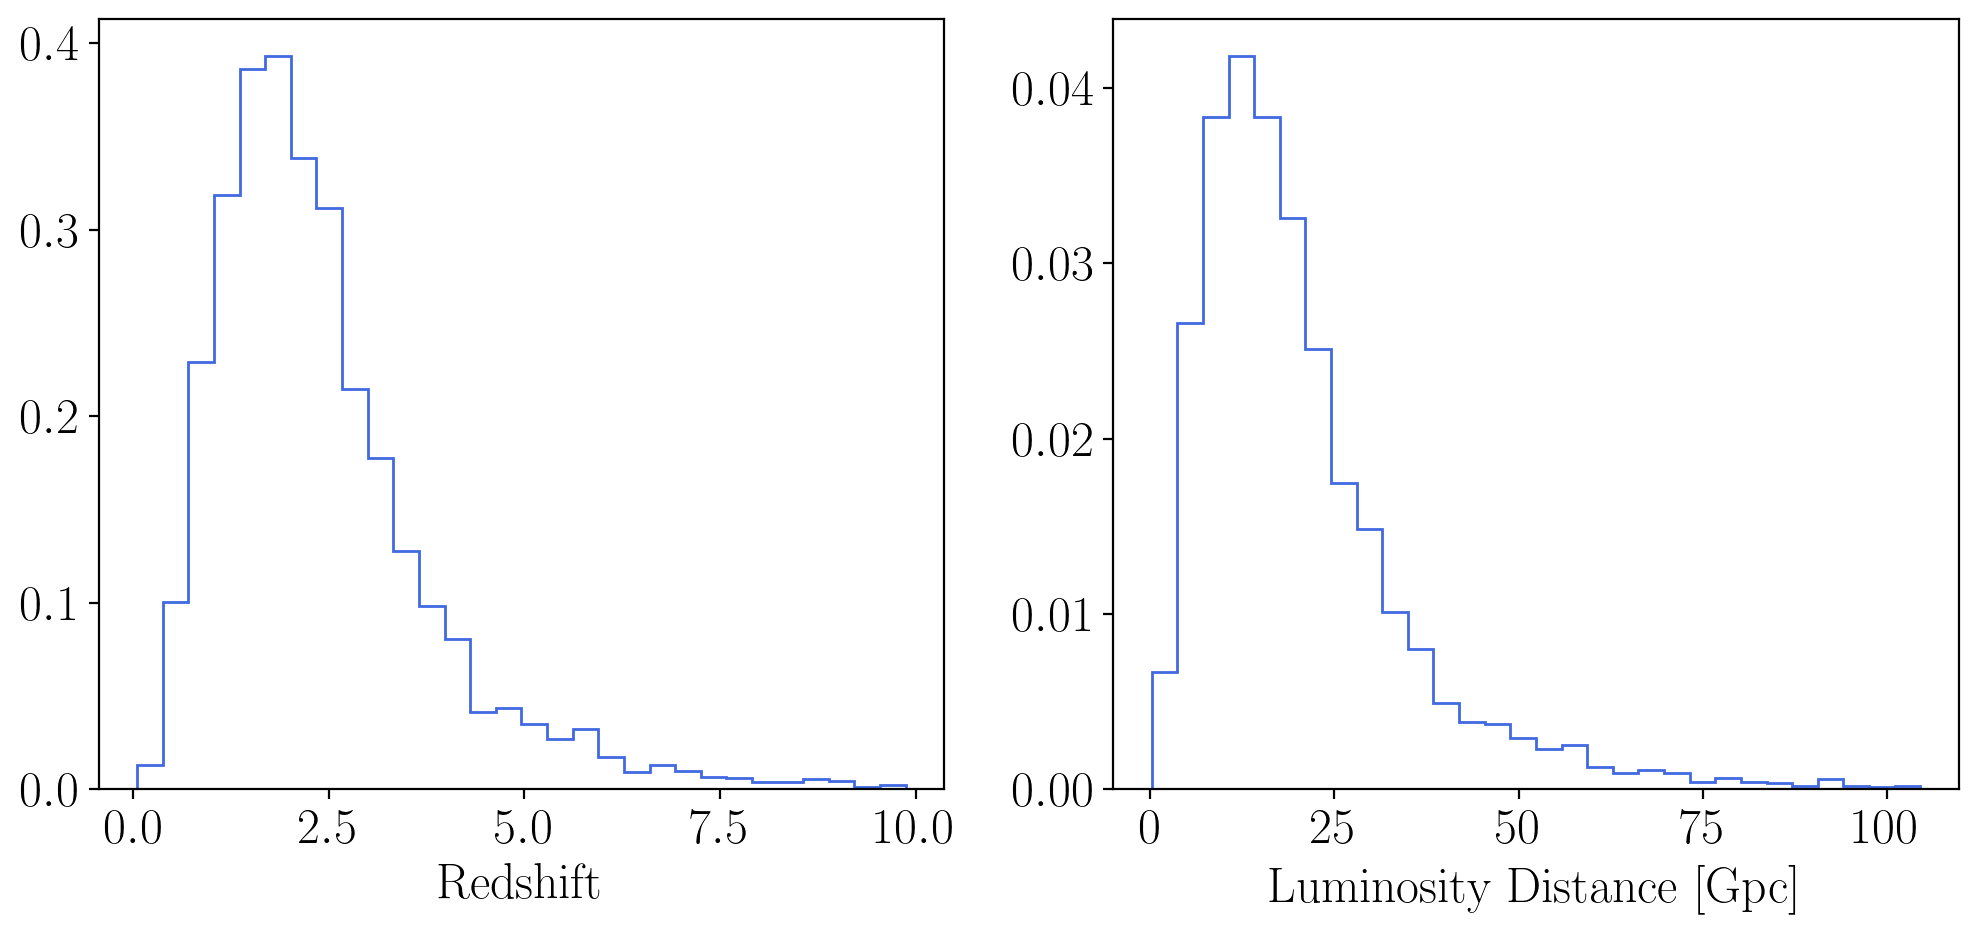

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs[0].hist(z_dict['z'], bins=30, density=True, histtype='step', lw=2, color='royalblue')
axs[0].set_xlabel('Redshift')
axs[1].hist(z_dict['dL'],bins=30, density=True, histtype='step', lw=2, color='royalblue')
axs[1].set_xlabel('Luminosity Distance $[\\rm{Gpc}]$')
plt.show()


### Masses

In [9]:
mass_hyperpars = {'alpha_m':2.5, 'beta_q':1.1, 'm_min':100., 'm_max':5000.}

MyMassDist = TruncatedPowerLaw_MassDistribution(hyperparameters=mass_hyperpars)

In [10]:
mass_dict = MyMassDist.sample_population(Nevents)

<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\o'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\o'
/var/folders/04/59g9g55x7qqcmhl8pk4ctcf40000gn/T/ipykernel_55601/217406869.py:6: SyntaxWarning: invalid escape sequence '\o'
  axs[0].set_xlabel('Mass $[M_\odot]$')
/var/folders/04/59g9g55x7qqcmhl8pk4ctcf40000gn/T/ipykernel_55601/217406869.py:7: SyntaxWarning: invalid escape sequence '\o'
  axs[0].set_xlabel('Mass $[M_\odot]$')


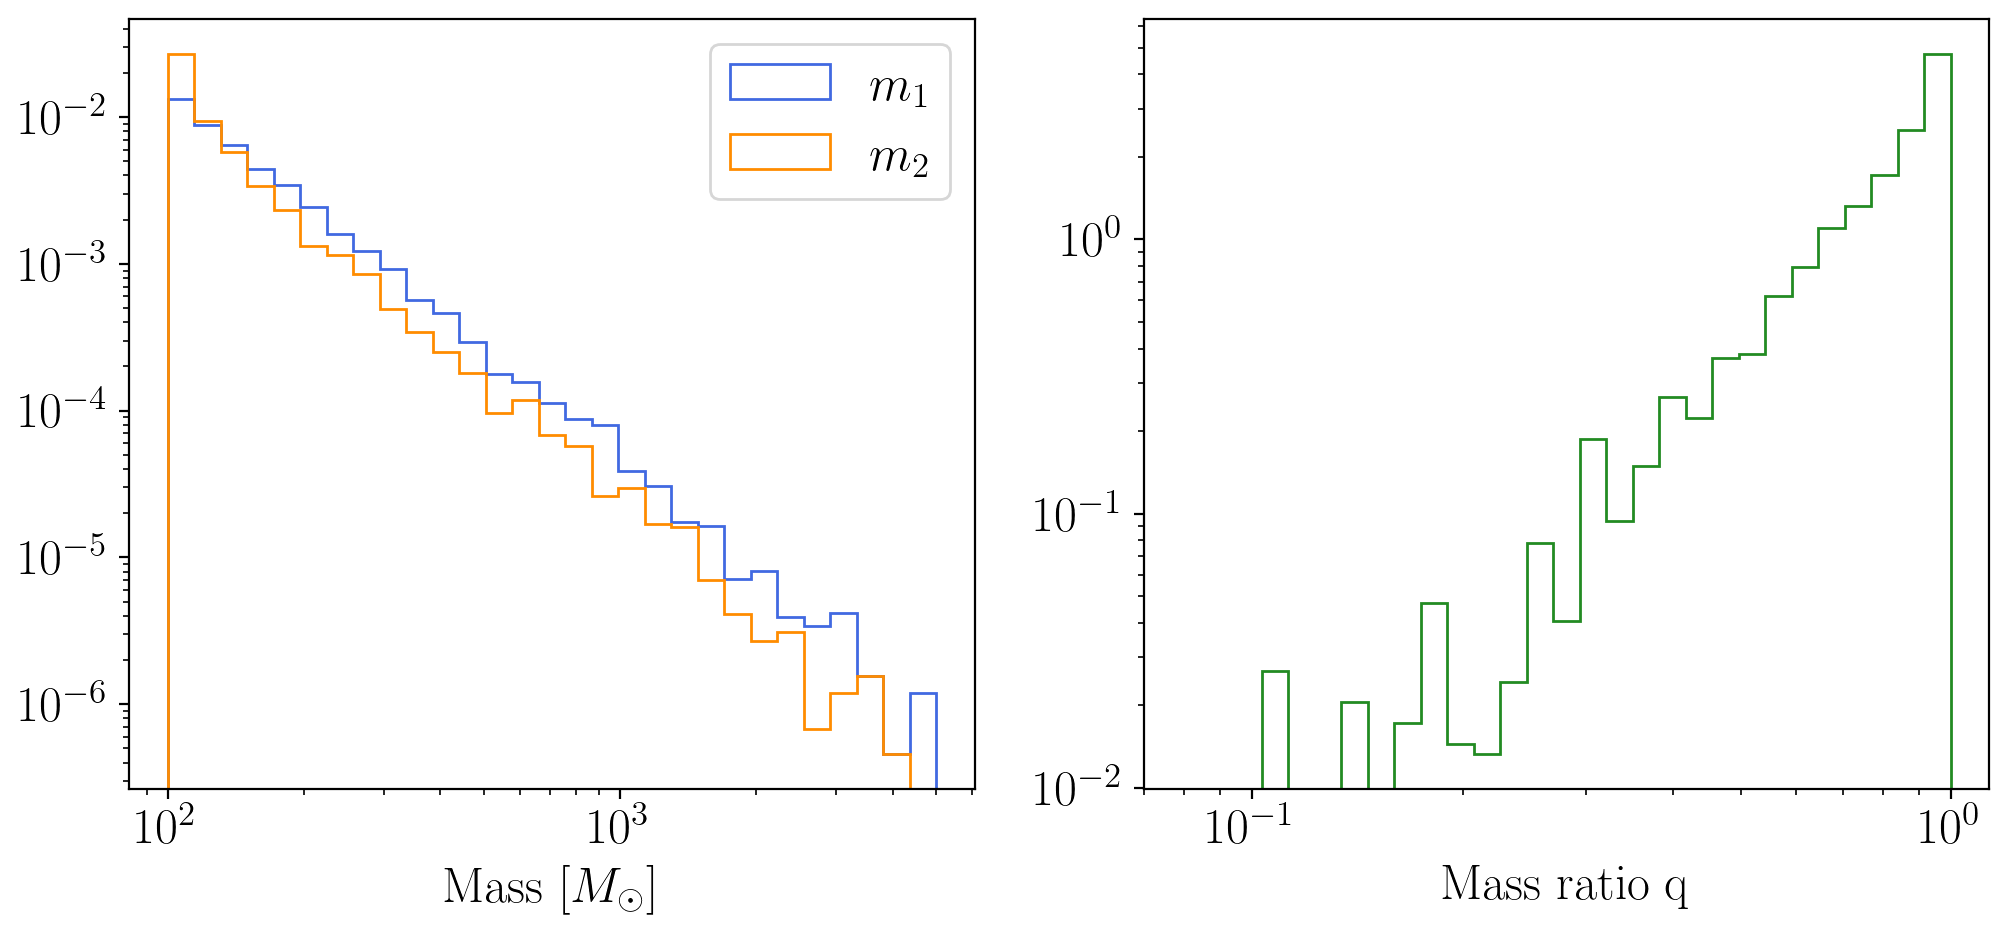

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12,5))

bins = np.logspace(2, np.log10(5000), 30)
axs[0].hist(mass_dict['m1_src'], bins=bins, density=True, histtype='step', lw=2, color='royalblue',label='$m_1$')
axs[0].hist(mass_dict['m2_src'], bins=bins, density=True, histtype='step', lw=2, color='darkorange',label='$m_2$')
axs[0].set_xlabel('Mass $[M_\odot]$')
axs[0].set_xlabel('Mass $[M_\odot]$')
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].legend()

bins = np.logspace(-1.1, 0, 30)
axs[1].hist(mass_dict['m2_src']/mass_dict['m1_src'], bins=bins, density=True, histtype='step', lw=2, color='forestgreen')
axs[1].set_xlabel('Mass ratio q')
axs[1].set_xscale('log')
axs[1].set_yscale('log')

plt.show()

### Spins 

In [16]:
seed = 42

rng1 = np.random.default_rng(seed)
rng2 = np.random.default_rng(seed+1)

spin_dict = {'chi1z': rng1.uniform(-0.9, 0.9, Nevents),
             'chi2z': rng2.uniform(-0.9, 0.9, Nevents)}

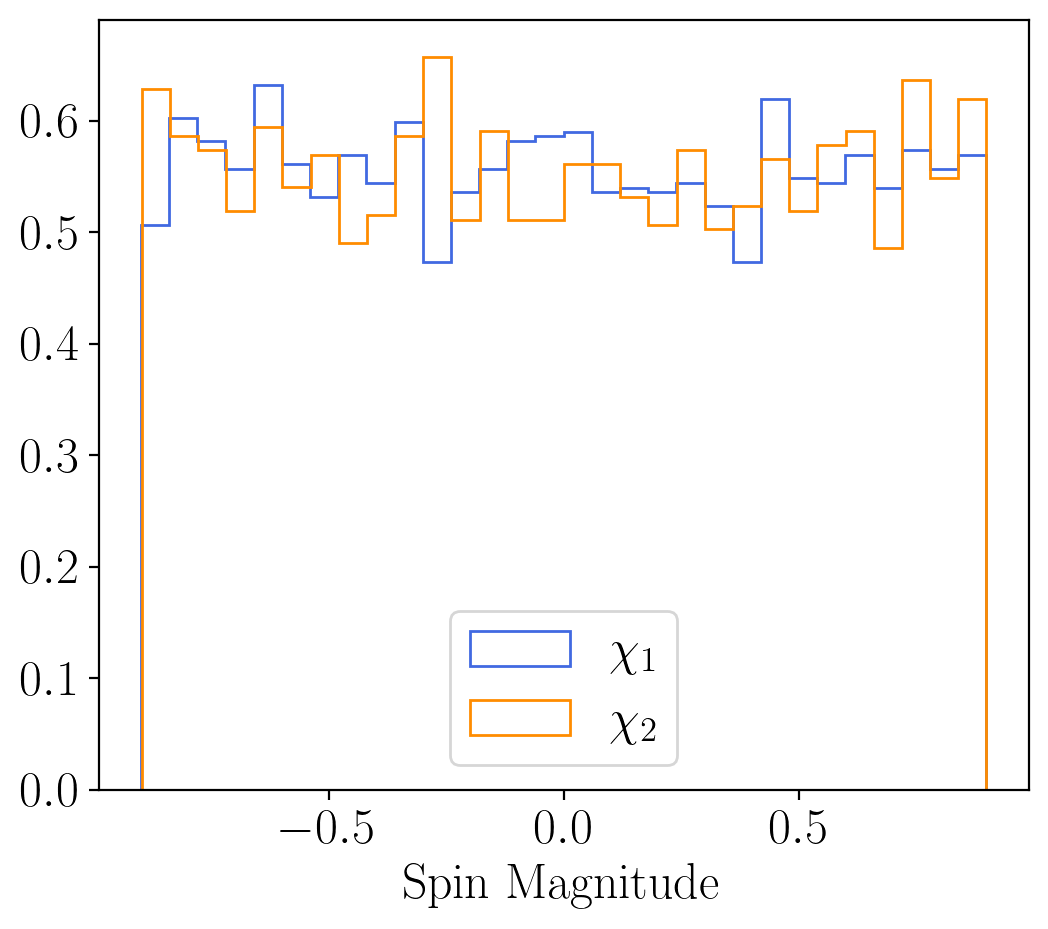

In [17]:
fig, axs = plt.subplots(1, 1, figsize=(6,5))

axs.hist(spin_dict['chi1z'], bins=30, density=True, histtype='step', lw=2, color='royalblue',label='$\\chi_1$')
axs.hist(spin_dict['chi2z'], bins=30, density=True, histtype='step', lw=2, color='darkorange',label='$\\chi_2$')
axs.set_xlabel('Spin Magnitude')
axs.legend()

plt.show()

## Converting into GWFast catalog

In [ ]:
pop_dict = {**mass_dict, **z_dict, **spin_dict}

# Sampling angular variables isotropically
rng_psi = np.random.default_rng(seed+2)
rng_thetaJN = np.random.default_rng(seed+3)
rng_theta = np.random.default_rng(seed+4)
rng_phi = np.random.default_rng(seed+5)

pop_dict['psi'] = rng_psi.uniform(0, np.pi, Nevents)
pop_dict['thetaJN'] = np.arccos(rng_thetaJN.uniform(-1, 1, Nevents))

pop_dict['theta'] = np.arccos(rng_theta.uniform(-1, 1, Nevents))
pop_dict['phi'] = rng_phi.uniform(0, 2*np.pi, Nevents)
pop_dict['ra'] = pop_dict['phi']
pop_dict['dec'] = np.pi/2. - pop_dict['theta']

# Sampling coalescence phase and time uniformly
rng_phicoal = np.random.default_rng(seed+6)
rng_tcoal = np.random.default_rng(seed+7)
pop_dict['Phicoal'] = rng_phicoal.uniform(0, 2*np.pi, Nevents)
pop_dict['tcoal'] = rng_tcoal.uniform(0, 1, Nevents)

# Computing Mc and eta in detector frame
m1_det = pop_dict['m1_src']*(1.+pop_dict['z'])
m2_det = pop_dict['m2_src']*(1.+pop_dict['z'])
pop_dict['Mc'] = ((m1_det*m2_det)**(3./5.))/((m1_det+m2_det)**(1./5.))
pop_dict['eta'] = (m1_det*m2_det)/((m1_det+m2_det)*(m1_det+m2_det))

pop_dict.keys()

dict_keys(['m1_src', 'm2_src', 'z', 'dL', 'chi1z', 'chi2z', 'psi', 'thetaJN', 'theta', 'phi', 'ra', 'dec', 'Phicoal', 'tcoal', 'Mc', 'eta'])

In [19]:
# Saving samples in a h5 file
import h5py
fname = 'IMBH_cat_1yr.h5'
with h5py.File(fname, 'w') as out:
        
                
    def cd(n, d):
        d = np.array(d)
        out.create_dataset(n, data=d, compression='gzip', shuffle=True)
    
    for key in pop_dict.keys():
        cd(key, pop_dict[key])